### Problem Statement
Build a neural network that learns the OR gate.

Dataset:
| x1 | x2 | Output |
| -- | -- | ------ |
| 0  | 0  | 0      |
| 0  | 1  | 1      |
| 1  | 0  | 1      |
| 1  | 1  | 1      |


This is a binary classification problem.


### Architecture
A single neuron is sufficient.

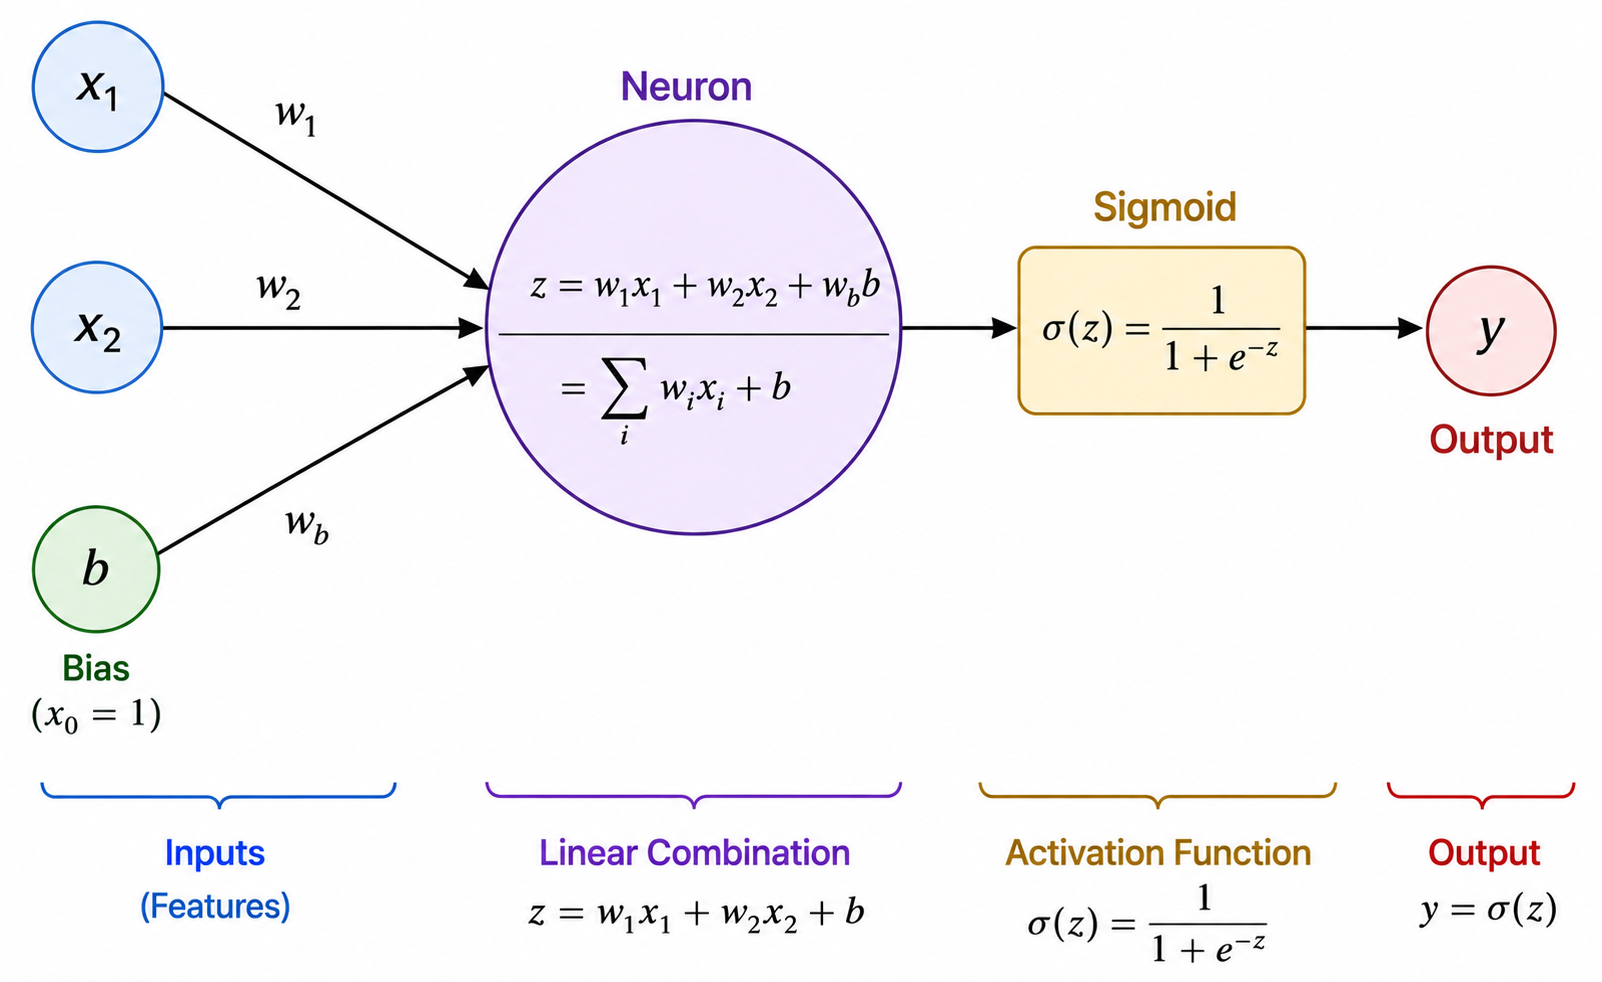

Mathematically:
```
z = x1*w1 + x2*w2 + b

ŷ = sigmoid(z)
```

### Training Flow
Every epoch:
```
Input
  ↓
Forward Propagation
  ↓
Prediction
  ↓
Loss
  ↓
Backpropagation
  ↓
Gradient Descent
  ↓
Updated Weights
```

In [1]:
import numpy as np

In [2]:
# Dataset

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([
    [0],
    [1],
    [1],
    [1]
])

In [3]:
# Parameters

np.random.seed(42)
W = np.random.randn(2, 1)
b = np.zeros((1, 1))
learning_rate = 0.1
epochs = 5000

In [4]:
# Activation

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [5]:
# Training Loop

for epoch in range(epochs):
    # Forward Propagation

    Z = np.dot(X, W) + b
    A = sigmoid(Z)

    # Loss
    loss = -np.mean(
        y*np.log(A+1e-8)
        +
        (1-y)*np.log(1-A+1e-8)
    )

    # Backpropagation
    dZ = A - y
    dW = np.dot(X.T, dZ) / len(X)
    db = np.sum(dZ) / len(X)

    # Gradient Descent
    W -= learning_rate * dW
    b -= learning_rate * db
    
    if epoch % 500 == 0:
        print(
            f"Epoch {epoch} Loss: {loss:.4f}"
        )

print("\nTraining Complete")

Epoch 0 Loss: 0.6158
Epoch 500 Loss: 0.1534
Epoch 1000 Loss: 0.0888
Epoch 1500 Loss: 0.0615
Epoch 2000 Loss: 0.0468
Epoch 2500 Loss: 0.0376
Epoch 3000 Loss: 0.0314
Epoch 3500 Loss: 0.0269
Epoch 4000 Loss: 0.0235
Epoch 4500 Loss: 0.0209

Training Complete


In [6]:
predictions = sigmoid(
    np.dot(X, W) + b
)

print(predictions)

[[0.04116319]
 [0.9835746 ]
 [0.98360636]
 [0.99998805]]


### Summary
| Concept             | Code                   |
| ------------------- | ---------------------- |
| Neuron              | `Z = XW + b`           |
| Activation          | `sigmoid()`            |
| Forward Propagation | `A = sigmoid(Z)`       |
| Loss Function       | BCE calculation        |
| Backpropagation     | `dZ`, `dW`, `db`       |
| Gradient Descent    | Weight update          |
| Training Loop       | `for epoch in range()` |

### What PyTorch Automates
The code above manually handles:
```
Forward Pass
Loss
Gradients
Weight Updates
```
PyTorch automates most of this.

Equivalent PyTorch training:
```python
loss.backward()

optimizer.step()
```